# Parte 3.2 — Exploração visual

**Objetivo desta parte:** menos sobre escrever código, mais sobre **interpretar
gráficos**. Cada seção traz uma pergunta orientadora — tente responder olhando para
o gráfico antes de ler o comentário logo abaixo dele.

Usamos os dados tratados (granularidade horária) e a visão diária (Parte 3) geradas
anteriormente.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

PROCESSED_DIR = Path("../data/processed")

horario = pd.read_csv(PROCESSED_DIR / "clima_tratado.csv", parse_dates=["datetime"])
diario = pd.read_csv(PROCESSED_DIR / "clima_diario.csv", parse_dates=["data"])

horario.head()


,cidade,datetime,temp_c,umidade_pct,precipitacao_mm,vento_kmh
0,manaus,2025-01-01 00:00:00,26.7,90.0,0.0,6.4
1,manaus,2025-01-01 01:00:00,26.6,91.0,0.0,5.6
2,manaus,2025-01-01 02:00:00,26.6,92.0,0.0,6.5
3,manaus,2025-01-01 03:00:00,26.5,93.0,0.0,6.1
4,manaus,2025-01-01 04:00:00,25.7,94.0,0.0,2.5


## 1. Distribuição de temperatura por cidade

**Pergunta:** qual cidade tem a maior amplitude térmica (diferença entre extremos)?
Qual tem a distribuição mais "apertada" (mais previsível)?


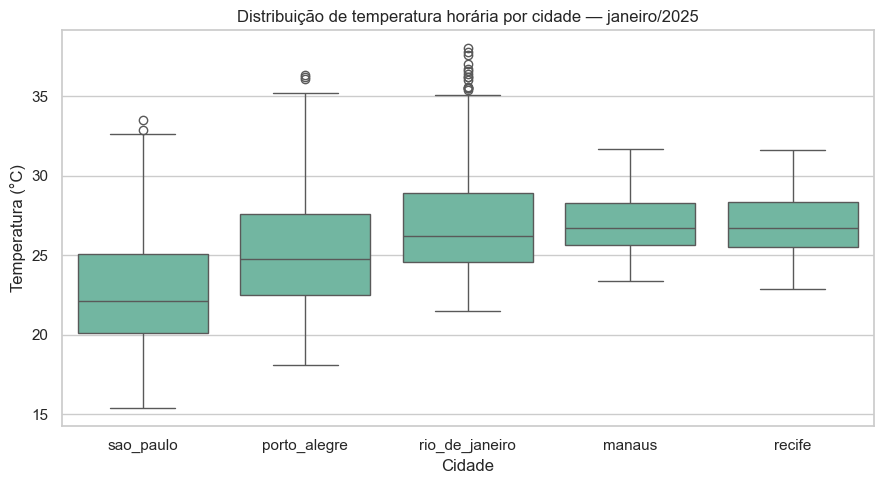

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem_cidades = horario.groupby("cidade")["temp_c"].median().sort_values().index

sns.boxplot(data=horario, x="cidade", y="temp_c", order=ordem_cidades, ax=ax)
ax.set_title("Distribuição de temperatura horária por cidade — janeiro/2025")
ax.set_xlabel("Cidade")
ax.set_ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()


Manaus e Recife, por serem equatorial/tropical costeira, tendem a mostrar caixas
mais "curtas" (menos variação ao longo do mês); Porto Alegre, mais ao sul, costuma
aparecer com temperaturas mais baixas e por vezes maior amplitude entre mínimas e
máximas diárias.


## 2. Série temporal — evolução diária

**Pergunta:** existe alguma cidade com um "evento" isolado (um pico ou queda breve)
que se destaca do padrão das demais?


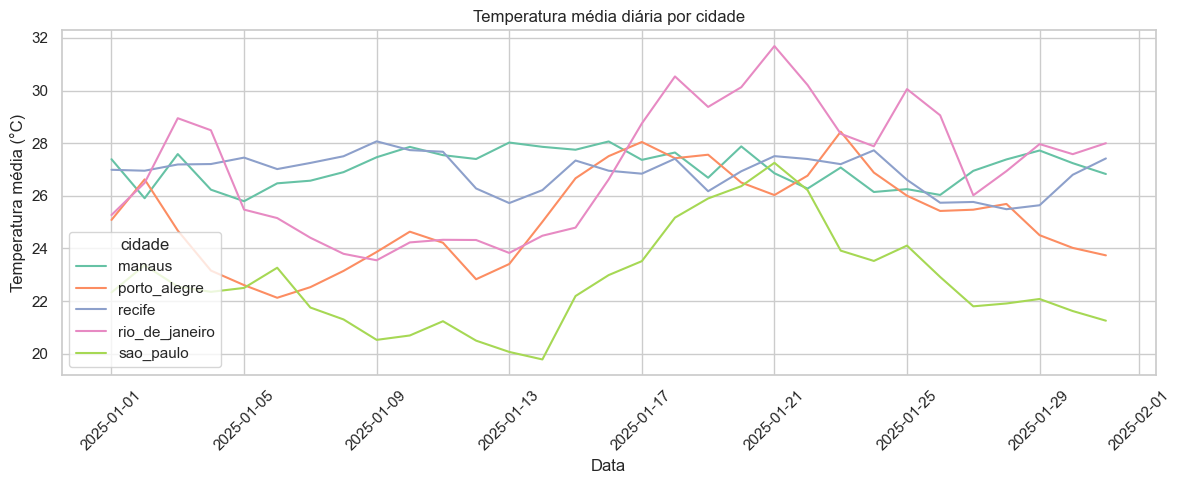

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=diario, x="data", y="temp_media", hue="cidade", ax=ax)
ax.set_title("Temperatura média diária por cidade")
ax.set_xlabel("Data")
ax.set_ylabel("Temperatura média (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Dado bruto vs. média móvel

**Pergunta:** a média móvel de 7 dias esconde ou revela melhor a tendência do que a
série diária crua? Em que situação você usaria uma e não a outra?


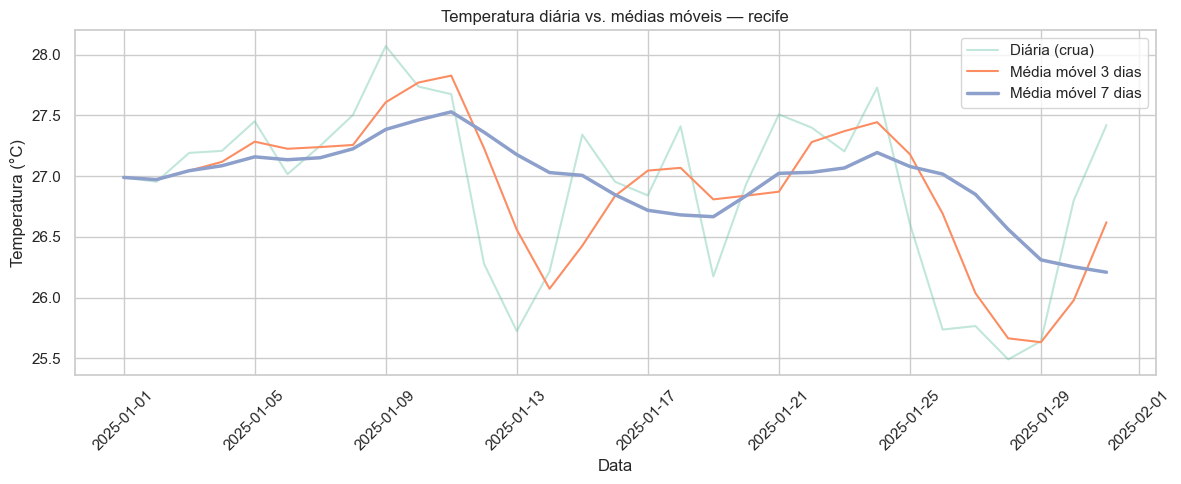

In [4]:
cidade_exemplo = "recife"
subset = diario[diario["cidade"] == cidade_exemplo]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(subset["data"], subset["temp_media"], alpha=0.4, label="Diária (crua)")
ax.plot(subset["data"], subset["media_movel_3d"], label="Média móvel 3 dias")
ax.plot(subset["data"], subset["media_movel_7d"], linewidth=2.5, label="Média móvel 7 dias")
ax.set_title(f"Temperatura diária vs. médias móveis — {cidade_exemplo}")
ax.set_xlabel("Data")
ax.set_ylabel("Temperatura (°C)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Relação entre temperatura e umidade

**Pergunta:** a relação parece a mesma em todas as cidades, ou alguma foge do
padrão geral (ex.: Manaus, tipicamente quente **e** muito úmida ao mesmo tempo)?


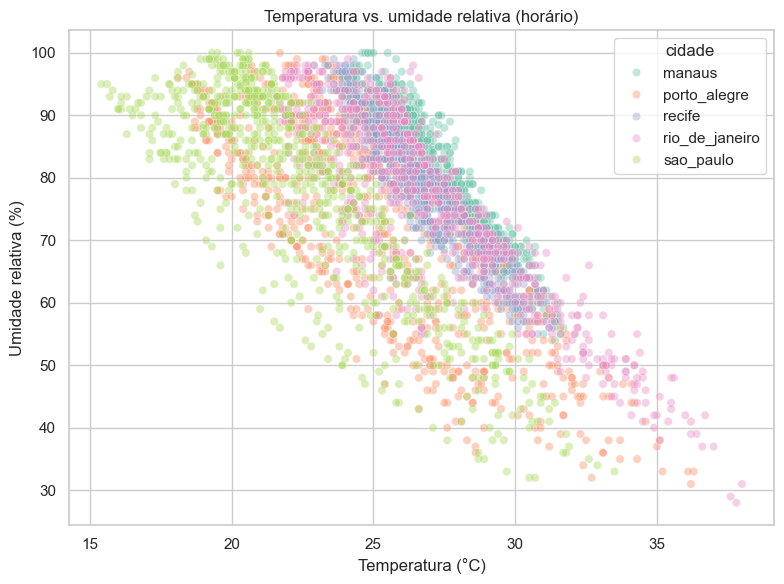

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=horario, x="temp_c", y="umidade_pct", hue="cidade", alpha=0.4, ax=ax)
ax.set_title("Temperatura vs. umidade relativa (horário)")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Umidade relativa (%)")
plt.tight_layout()
plt.show()


## 5. Correlação entre variáveis

**Pergunta:** vento e precipitação estão correlacionados? Faz sentido fisicamente
essa correlação ser fraca ou forte no seu resultado?


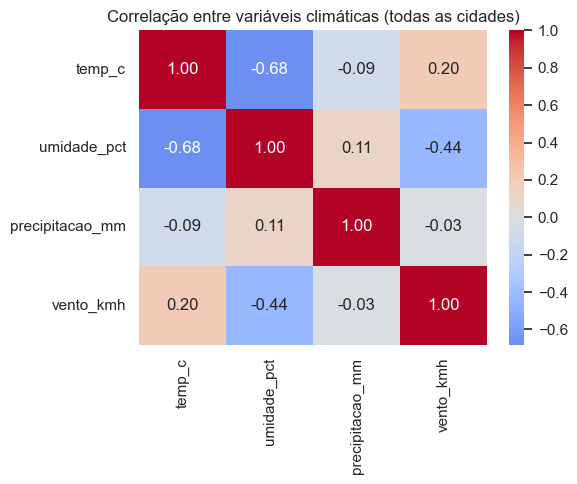

In [6]:
matriz_correlacao = horario[["temp_c", "umidade_pct", "precipitacao_mm", "vento_kmh"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre variáveis climáticas (todas as cidades)")
plt.tight_layout()
plt.show()


## 6. Comparativo entre cidades ao longo do tempo (heatmap)

Uma forma compacta de ver todas as 5 cidades e todos os dias do mês em uma única
imagem — bom para identificar rapidamente ondas de calor ou frio que atingem
várias cidades ao mesmo tempo (colunas mais quentes/frias na vertical).


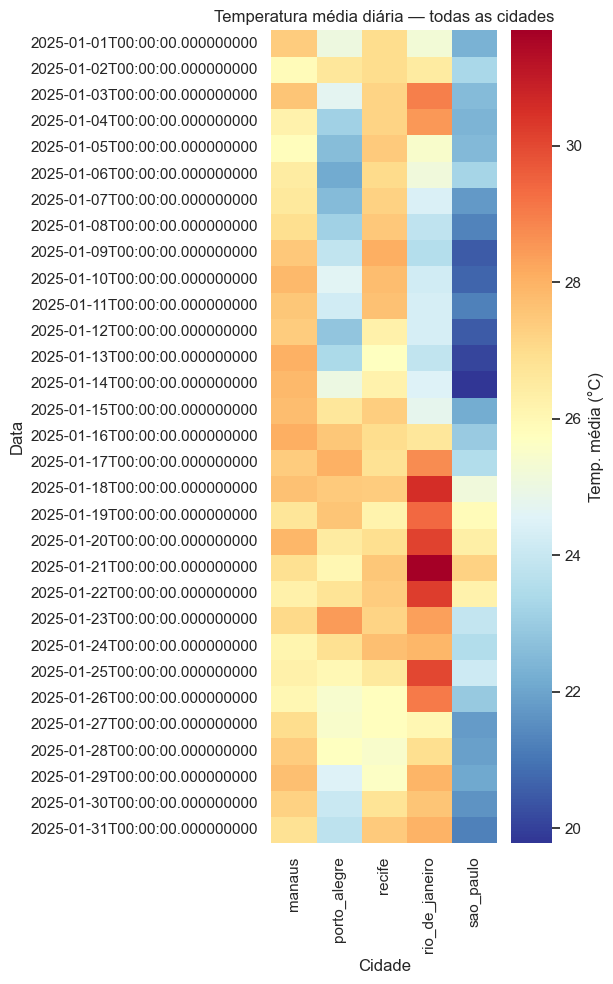

In [7]:
pivot_temp = pd.read_csv(PROCESSED_DIR / "clima_pivot_temp.csv", index_col="data", parse_dates=True)

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(pivot_temp, cmap="RdYlBu_r", ax=ax, cbar_kws={"label": "Temp. média (°C)"})
ax.set_title("Temperatura média diária — todas as cidades")
ax.set_xlabel("Cidade")
ax.set_ylabel("Data")
plt.tight_layout()
plt.show()


## 7. Precipitação acumulada por cidade

**Pergunta:** o total de chuva no mês bate com a intuição climática de cada
cidade (ex.: Recife/Manaus tipicamente mais chuvosas em janeiro do que Porto
Alegre)?


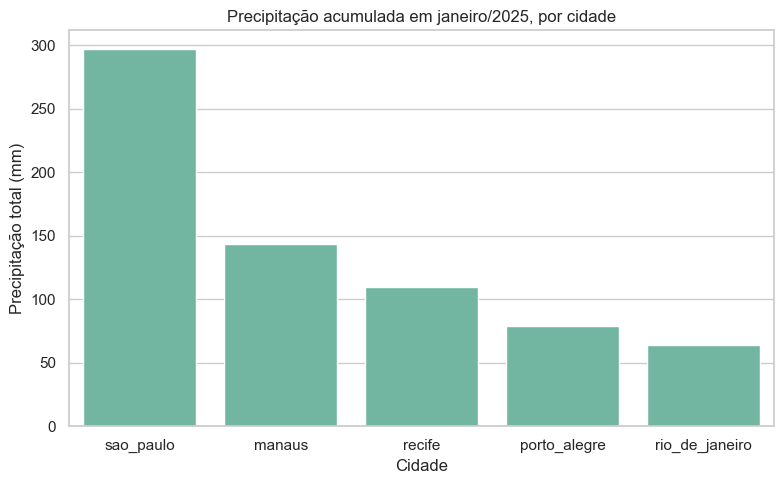

In [8]:
precipitacao_total_cidade = (
    diario.groupby("cidade")["precipitacao_total"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=precipitacao_total_cidade.index, y=precipitacao_total_cidade.values, ax=ax)
ax.set_title("Precipitação acumulada em janeiro/2025, por cidade")
ax.set_xlabel("Cidade")
ax.set_ylabel("Precipitação total (mm)")
plt.tight_layout()
plt.show()


## Para discutir

- Qual cidade parece climatologicamente mais **estável** ao longo do mês, e qual
  mais **variável**? Que gráfico acima sustenta essa resposta?
- Se você tivesse que escolher **uma única cidade adicional** para acrescentar à
  comparação (ex. Curitiba, Brasília, Belém), qual escolheria para maximizar a
  diversidade climática da amostra? Por quê?
- A correlação entre temperatura e umidade observada aqui é a mesma que você
  esperaria para o inverno (ao invés de janeiro/verão)? O que mudaria?
